In [3]:
import pandas as pd
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [4]:
import pandas as pd

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

# Convert y_test into a 1D array
y_test = y_test.values.ravel()

print("Test data loaded successfully!")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Test data loaded successfully!
X_test shape: (10221, 7)
y_test shape: (10221,)


In [5]:
import joblib
model = joblib.load("../models/best_model.pkl")
print("Best model loaded successfully!")

Best model loaded successfully!


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [6]:
y_pred = model.predict(X_test)
print("Predictions generated successfully!")

Predictions generated successfully!


In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Model Evaluation Metrics")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Model Evaluation Metrics
----------------------------------------
Accuracy : 0.8128
Precision: 0.7470
Recall   : 0.8128
F1 Score : 0.7385


In [8]:
from sklearn.metrics import classification_report

print("Classification Report")
print("=" * 50)

print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       0.42      0.04      0.08       866
           1       0.44      0.01      0.02       815
           2       0.56      0.04      0.08       238
           3       0.82      0.99      0.90      8302

    accuracy                           0.81     10221
   macro avg       0.56      0.27      0.27     10221
weighted avg       0.75      0.81      0.74     10221



In [9]:
from sklearn.metrics import roc_auc_score

# Get prediction probabilities for all classes
y_prob = model.predict_proba(X_test)

# Calculate ROC-AUC for multiclass classification
roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print(f"Weighted ROC-AUC Score: {roc_auc:.4f}")

Weighted ROC-AUC Score: 0.7482


In [10]:
print("Class Distribution in Test Set")
print("-" * 35)

class_counts = pd.Series(y_test).value_counts().sort_index()
print(class_counts)

Class Distribution in Test Set
-----------------------------------
0     866
1     815
2     238
3    8302
Name: count, dtype: int64


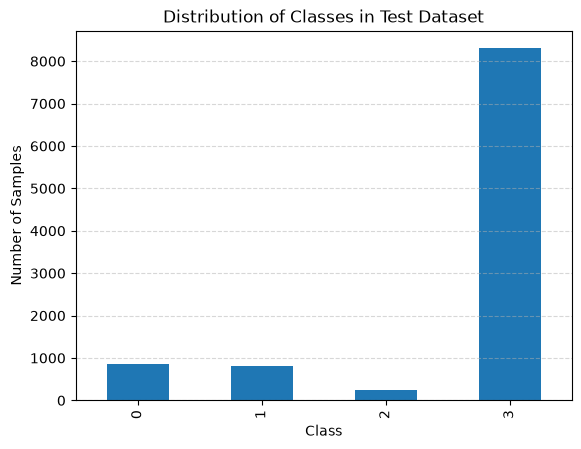

In [11]:
import matplotlib.pyplot as plt

class_counts.plot(kind="bar")

plt.title("Distribution of Classes in Test Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [12]:
from sklearn.metrics import classification_report

print("Classification Report")
print("-" * 50)

print(classification_report(y_test, y_pred))

Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.42      0.04      0.08       866
           1       0.44      0.01      0.02       815
           2       0.56      0.04      0.08       238
           3       0.82      0.99      0.90      8302

    accuracy                           0.81     10221
   macro avg       0.56      0.27      0.27     10221
weighted avg       0.75      0.81      0.74     10221



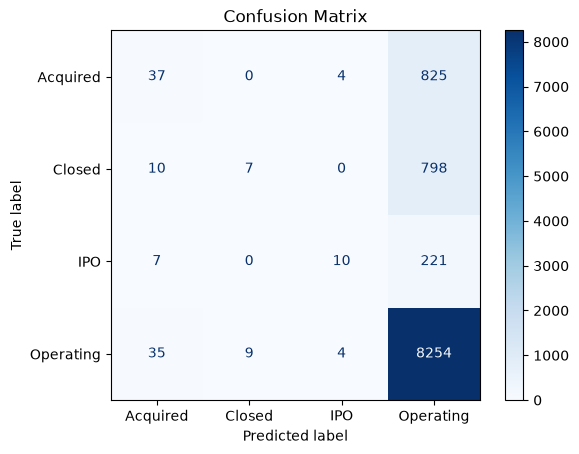

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

labels = ["Acquired", "Closed", "IPO", "Operating"]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [14]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Score
0,Accuracy,0.812836
1,Precision,0.746970
2,Recall,0.812836
3,F1 Score,0.738457
4,ROC-AUC,0.748216


In [15]:
print("Model Evaluation Summary")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nConclusion:")
print("The Random Forest model achieved good overall accuracy and ROC-AUC score.")
print("However, the classification report shows that the model performs significantly better on the majority class than on the minority classes.")
print("This indicates that the dataset is imbalanced, causing the model to favor the dominant class.")
print("Future work can improve performance by applying techniques such as class balancing, oversampling (SMOTE), or hyperparameter tuning.")

Model Evaluation Summary
Accuracy  : 0.8128
Precision : 0.7470
Recall    : 0.8128
F1 Score  : 0.7385
ROC-AUC   : 0.7482

Conclusion:
The Random Forest model achieved good overall accuracy and ROC-AUC score.
However, the classification report shows that the model performs significantly better on the majority class than on the minority classes.
This indicates that the dataset is imbalanced, causing the model to favor the dominant class.
Future work can improve performance by applying techniques such as class balancing, oversampling (SMOTE), or hyperparameter tuning.
